# 02 · Qualitative Risk Assessment
### Pfizer–Seagen Enterprise Risk Management — Group 10

**Purpose.** Formalise the qualitative assessment that follows the EDA: the SWOT that
generated the risk set, the 1–10 likelihood×impact scoring methodology, the severity
distribution, the corrected priority heatmap, and the decision about which risks advance
to quantitative modelling.

**Methods.** Scenario Analytics (Fleisher & Bensoussan, 2015, Ch. 22) and Industry Fusion
Analytics (Ch. 17), within a COSO (2017) enterprise-risk frame.

**Pipeline position:** `eda.ipynb` → **`qualitative_analysis.ipynb`** → `quantitative_analysis.ipynb` → `monte_carlo.ipynb`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 70)

from pathlib import Path
def find_data(name):
    """Locate a data file whether run inside the repo or standalone."""
    for base in ["../data/raw", "../data/processed", "data/raw", ".", "/mnt/user-data/uploads"]:
        candidate = Path(base) / name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {name}")


register_rows = [
 ("R-001","Interest coverage ratio falling below safe levels due to acquisition debt load","Financial",7,9,"High"),
 ("R-002","Failure to achieve $10B Seagen 2030 risk-adjusted revenue target","Financial",7,9,"High"),
 ("R-003","IRA Medicare drug-price negotiations compress Seagen ADC revenue","Legal/Reg.",8,8,"High"),
 ("R-004","FDA CRL or labelling restriction on Seagen pipeline ADC submissions","Legal/Reg.",6,7,"Medium"),
 ("R-005","Patent cliff and ADCETRIS biosimilar entry risk","Legal/Reg.",6,8,"Medium"),
 ("R-006","Key ADC talent attrition from former Seagen organization","Operational",8,9,"Critical"),
 ("R-007","ADC manufacturing scale-up failure at Seagen's Bothell facility","Operational",6,8,"Medium"),
 ("R-008","Clinical trial continuity disruption across Seagen's 30+ active INDs","Operational",5,7,"Medium"),
 ("R-009","IT systems and data harmonization cost overrun and timeline delay","Operational",5,6,"Medium"),
 ("R-010","ADC combination therapy first-mover opportunity (positive risk)","Strategic",7,8,"High"),
 ("R-011","Synergy realization shortfall against $1B target","Financial",6,7,"Medium"),
 ("R-012","Goodwill impairment and DCF value erosion","Financial",5,9,"Medium"),
 ("R-013","Free cash flow and dividend sustainability pressure","Financial",6,8,"Medium"),
 ("R-014","Antitrust post-close compliance and FTC ongoing scrutiny","Legal/Reg.",4,6,"Low"),
 ("R-015","Active litigation and ADC IP dispute risk","Legal/Reg.",5,8,"Medium"),
 ("R-016","R&D pipeline integration disruption across 60 combined programs","Operational",6,8,"Medium"),
 ("R-017","Cybersecurity breach or ransomware exposure during system integration","Technology",6,9,"High"),
 ("R-018","ESG and reputational risk from post-acquisition workforce reduction","Strategic",5,6,"Medium"),
 ("R-019","Payer and GPO concentration risk affecting ADC reimbursement","Financial",5,7,"Medium"),
 ("R-020","Foreign-exchange exposure on ex-US ADC revenue and trial costs","Financial",4,5,"Low"),
]
reg = pd.DataFrame(register_rows, columns=["RiskID","Risk","Category","Likelihood","Impact","Priority"])
reg["Score"] = reg["Likelihood"] * reg["Impact"]
reg["Added_in_revision"] = reg["RiskID"].isin(["R-017","R-018","R-019","R-020"])

print(f'Loaded {len(reg)}-risk register.')
reg.head()

Loaded 20-risk register.


,RiskID,Risk,Category,Likelihood,Impact,Priority,Score,Added_in_revision
0,R-001,Interest coverage ratio falling below safe levels due to acquisition debt load,Financial,7,9,High,63,False
1,R-002,Failure to achieve $10B Seagen 2030 risk-adjusted revenue target,Financial,7,9,High,63,False
2,R-003,IRA Medicare drug-price negotiations compress Seagen ADC revenue,Legal/Reg.,8,8,High,64,False
3,R-004,FDA CRL or labelling restriction on Seagen pipeline ADC submissions,Legal/Reg.,6,7,Medium,42,False
4,R-005,Patent cliff and ADCETRIS biosimilar entry risk,Legal/Reg.,6,8,Medium,48,False


## 1. SWOT analysis (Better SWOT)
Risks were generated from an evidence-based SWOT — future-oriented, specific and tied to
named competitors and disclosed figures rather than generic commentary.

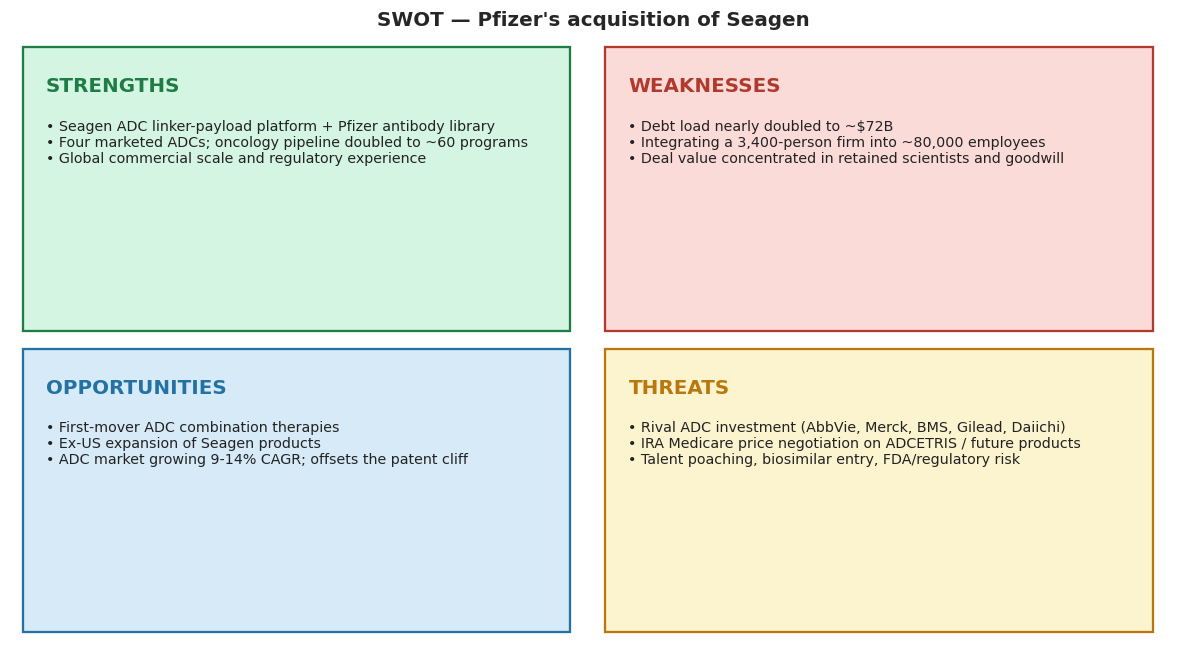

In [2]:
S = ["Seagen ADC linker-payload platform + Pfizer antibody library",
     "Four marketed ADCs; oncology pipeline doubled to ~60 programs",
     "Global commercial scale and regulatory experience"]
W = ["Debt load nearly doubled to ~$72B",
     "Integrating a 3,400-person firm into ~80,000 employees",
     "Deal value concentrated in retained scientists and goodwill"]
O = ["First-mover ADC combination therapies",
     "Ex-US expansion of Seagen products",
     "ADC market growing 9-14% CAGR; offsets the patent cliff"]
T = ["Rival ADC investment (AbbVie, Merck, BMS, Gilead, Daiichi)",
     "IRA Medicare price negotiation on ADCETRIS / future products",
     "Talent poaching, biosimilar entry, FDA/regulatory risk"]
fig, ax = plt.subplots(figsize=(11, 6)); ax.axis("off"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
quad = [(0.0, 0.5, "STRENGTHS", S, "#D5F5E3", "#1E7D45"),
        (0.5, 0.5, "WEAKNESSES", W, "#FADBD8", "#B03A2E"),
        (0.0, 0.0, "OPPORTUNITIES", O, "#D6EAF8", "#2471A3"),
        (0.5, 0.0, "THREATS", T, "#FCF3CF", "#B9770E")]
for x, y, t, items, bg, fg in quad:
    ax.add_patch(plt.Rectangle((x + 0.01, y + 0.01), 0.47, 0.47, facecolor=bg, edgecolor=fg, lw=1.5))
    ax.text(x + 0.03, y + 0.43, t, fontsize=13, fontweight="bold", color=fg, va="top")
    ax.text(x + 0.03, y + 0.36, "\n".join("\u2022 " + it for it in items), fontsize=9.3, color="#222", va="top")
ax.set_title("SWOT \u2014 Pfizer's acquisition of Seagen", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 2. Scoring methodology — 1–10 likelihood × impact
Each risk is scored on a 1–10 scale for likelihood and impact; the risk score is their
product, and the priority band is derived from the score. The 1–10 scale (rather than
High/Med/Low) gives finer ranking and produces numbers that feed directly into the
quantitative model.

In [3]:
def priority_band(score):
    return "Low" if score < 30 else "Medium" if score < 50 else "High" if score < 70 else "Critical"

reg["Priority_check"] = reg["Score"].apply(priority_band)
assert (reg["Priority"] == reg["Priority_check"]).all(), "priority labels do not reconcile"
print("All 20 priority labels reconcile with their Score bands "
      "(Low<30, Medium 30-49, High 50-69, Critical 70+).")
reg.sort_values("Score", ascending=False)[["RiskID", "Risk", "Likelihood", "Impact", "Score", "Priority"]].head(8)

All 20 priority labels reconcile with their Score bands (Low<30, Medium 30-49, High 50-69, Critical 70+).


,RiskID,Risk,Likelihood,Impact,Score,Priority
5,R-006,Key ADC talent attrition from former Seagen organization,8,9,72,Critical
2,R-003,IRA Medicare drug-price negotiations compress Seagen ADC revenue,8,8,64,High
1,R-002,Failure to achieve $10B Seagen 2030 risk-adjusted revenue target,7,9,63,High
0,R-001,Interest coverage ratio falling below safe levels due to acquisition debt load,7,9,63,High
9,R-010,ADC combination therapy first-mover opportunity (positive risk),7,8,56,High
16,R-017,Cybersecurity breach or ransomware exposure during system integration,6,9,54,High
12,R-013,Free cash flow and dividend sustainability pressure,6,8,48,Medium
6,R-007,ADC manufacturing scale-up failure at Seagen's Bothell facility,6,8,48,Medium


## 3. Severity distribution

In [4]:
order = ["Critical", "High", "Medium", "Low"]
counts = reg["Priority"].value_counts().reindex(order)
print(counts.to_string())
print(f"\nSummary: {counts['Critical']} Critical, {counts['High']} High, "
      f"{counts['Medium']} Medium, {counts['Low']} Low.")
ct = pd.crosstab(reg["Category"], reg["Priority"]).reindex(columns=order, fill_value=0)
ct

Priority
Critical     1
High         5
Medium      12
Low          2

Summary: 1 Critical, 5 High, 12 Medium, 2 Low.


Priority,Critical,High,Medium,Low
Category,,,,
Financial,0,2,4,1
Legal/Reg.,0,1,3,1
Operational,1,0,4,0
Strategic,0,1,1,0
Technology,0,1,0,0


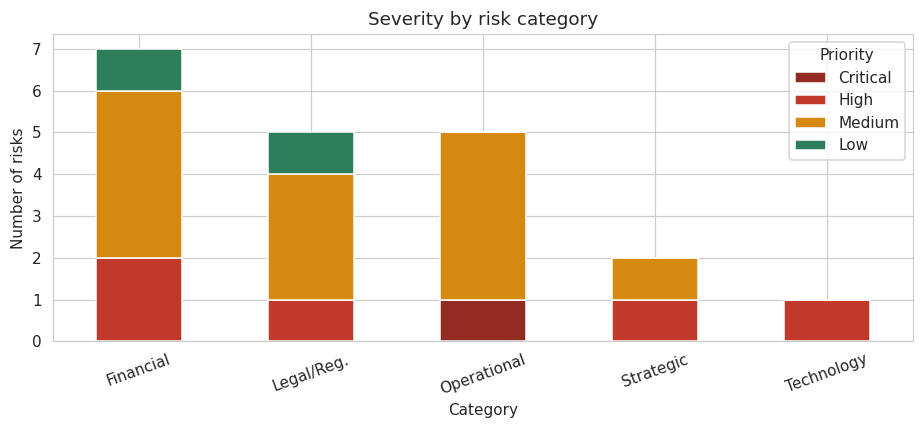

In [5]:
bandcol = {"Critical": "#922B21", "High": "#C0392B", "Medium": "#D68910", "Low": "#2E7D5B"}
ax = ct.plot(kind="bar", stacked=True, color=[bandcol[c] for c in ct.columns],
             figsize=(8.5, 4), edgecolor="white")
ax.set_ylabel("Number of risks"); ax.set_title("Severity by risk category")
ax.tick_params(axis="x", rotation=20); ax.legend(title="Priority")
plt.tight_layout(); plt.show()

## 4. Corrected risk heatmap
An earlier heatmap used a narrow rule (High only if Likelihood ≥ 8 **and** Impact ≥ 5) that
flagged just two risks and contradicted the register’s own priority column. The map below is
rebuilt on the same Priority bands as the register, so the visual and the written register
agree. Cell shade is the band of that cell’s Likelihood×Impact score.

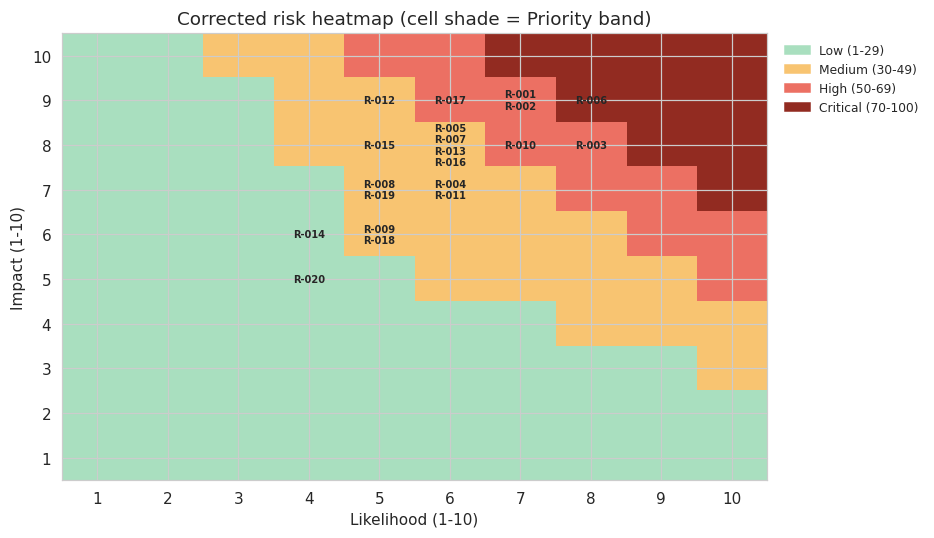

In [6]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mp

def band_idx(s):
    return 0 if s < 30 else 1 if s < 50 else 2 if s < 70 else 3

cmap = ListedColormap(["#A9DFBF", "#F8C471", "#EC7063", "#922B21"])
grid = np.zeros((10, 10), dtype=int)
for I in range(1, 11):
    for L in range(1, 11):
        grid[10 - I, L - 1] = band_idx(L * I)

cell = {}
for _, r in reg.iterrows():
    cell.setdefault((r.Likelihood, r.Impact), []).append(r.RiskID)

fig, ax = plt.subplots(figsize=(8.6, 5))
ax.imshow(grid, cmap=cmap, norm=BoundaryNorm([0, 1, 2, 3, 4], cmap.N), aspect="auto")
ax.set_xticks(range(10)); ax.set_xticklabels(range(1, 11))
ax.set_yticks(range(10)); ax.set_yticklabels(range(10, 0, -1))
ax.set_xlabel("Likelihood (1-10)"); ax.set_ylabel("Impact (1-10)")
ax.set_title("Corrected risk heatmap (cell shade = Priority band)")
for (L, I), rs in cell.items():
    ax.text(L - 1, 10 - I, "\n".join(rs), ha="center", va="center", fontsize=6.5, fontweight="bold")
leg = [mp.Patch(color="#A9DFBF", label="Low (1-29)"), mp.Patch(color="#F8C471", label="Medium (30-49)"),
       mp.Patch(color="#EC7063", label="High (50-69)"), mp.Patch(color="#922B21", label="Critical (70-100)")]
ax.legend(handles=leg, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 5. Risks selected for quantitative analysis
A risk advances to full quantitative modelling only if (a) the dollar exposure is large
enough that a point estimate is misleading, (b) it has observable leading indicators that
can be turned into a probability, and (c) the decision depends on the shape of the outcome,
not just its average. Three risks meet all three tests.

In [7]:
selection = pd.DataFrame([
    ("R-006", "Critical", "Critical ADC talent attrition",
     "Critical severity and highest likelihood; the people-risk the deal's science depends on"),
    ("R-MSE", "High (R-001/R-002 competitive cluster)", "ADC market-share erosion",
     "Largest financial exposure; observable competitor indicators; drives the $10B 2030 thesis"),
    ("R-010", "High", "First-mover combination-therapy upside",
     "Positive risk; time-limited window worth modelling as an offset to the threats"),
], columns=["Risk", "Priority", "Theme", "Why it advances to quantitative analysis"])
selection

,Risk,Priority,Theme,Why it advances to quantitative analysis
0,R-006,Critical,Critical ADC talent attrition,Critical severity and highest likelihood; the people-risk the deal's science depends on
1,R-MSE,High (R-001/R-002 competitive cluster),ADC market-share erosion,Largest financial exposure; observable competitor indicators; drives the $10B 2030 thesis
2,R-010,High,First-mover combination-therapy upside,Positive risk; time-limited window worth modelling as an offset to the threats


## 6. Qualitative findings & hand-off
- Severity is **concentrated, not spread**: one Critical and five High risks carry almost all the exposure, and they are overwhelmingly **competitive and financial**.
- The corrected heatmap now **agrees with the register**, removing the earlier rule-based inconsistency.
- Three risks — **R-006, R-MSE and R-010** — meet the criteria for quantification; the rest are better managed through monitoring (KRIs).

These three risks, and their I&W inputs, are carried into `quantitative_analysis.ipynb` (supervised modelling) and `monte_carlo.ipynb` (simulation).